In [ ]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
import numpy as np
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
import seaborn as sns

## 

In [22]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Check data                              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# Path relative to the root directory
file_path = "../../data/weather/weather_hourly.csv"

weather_data = pd.read_csv(file_path)
weather_data.head()

,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,surface_pressure,cloud_cover,wind_speed_10m,wind_speed_100m,is_day,sunshine_duration,direct_radiation
0,2024-01-01 00:00:00+00:00,-7.50,73.624560,-12.272507,0.0,0.0,0.0,0.0,891.08750,11.0,9.693296,13.797912,0.0,0.0,0.0
1,2024-01-01 01:00:00+00:00,-8.20,74.677930,-13.002723,0.0,0.0,0.0,0.0,890.57184,20.0,9.659814,12.429127,0.0,0.0,0.0
2,2024-01-01 02:00:00+00:00,-8.75,75.177630,-13.529382,0.0,0.0,0.0,0.0,889.95590,35.0,9.290511,9.693295,0.0,0.0,0.0
3,2024-01-01 03:00:00+00:00,-9.20,75.398346,-13.913002,0.0,0.0,0.0,0.0,889.04440,92.0,8.654987,6.489992,0.0,0.0,0.0
4,2024-01-01 04:00:00+00:00,-9.25,75.085120,-13.931759,0.0,0.0,0.0,0.0,888.67505,100.0,8.396570,3.415260,0.0,0.0,0.0


In [23]:
weather_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17568 entries, 0 to 17567
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  17568 non-null  str    
 1   temperature_2m        17568 non-null  float64
 2   relative_humidity_2m  17568 non-null  float64
 3   apparent_temperature  17568 non-null  float64
 4   precipitation         17568 non-null  float64
 5   rain                  17568 non-null  float64
 6   snowfall              17568 non-null  float64
 7   snow_depth            17568 non-null  float64
 8   surface_pressure      17568 non-null  float64
 9   cloud_cover           17568 non-null  float64
 10  wind_speed_10m        17568 non-null  float64
 11  wind_speed_100m       17568 non-null  float64
 12  is_day                17568 non-null  float64
 13  sunshine_duration     17568 non-null  float64
 14  direct_radiation      17568 non-null  float64
dtypes: float64(14), str(1)
memory 

In [24]:
# 1. Ensure date is a datetime object
weather_data['date'] = pd.to_datetime(weather_data['date'])

# 2. Filter for 2025 values only
weather_data = weather_data[weather_data['date'].dt.year == 2025].copy()

# 3. Clean: Drop any duplicate rows based on the timestamp
weather_data = weather_data.drop_duplicates(subset=['date'])

# 4. Feature Engineering: Extract time components to align with trip data
weather_data['start_month'] = weather_data['date'].dt.month
weather_data['start_hour'] = weather_data['date'].dt.hour
weather_data['day_name'] = weather_data['date'].dt.day_name()

# Define categorical order for months and days (useful for future plotting)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weather_data['day_name'] = pd.Categorical(weather_data['day_name'], categories=day_order, ordered=True)

# 5. Final Sorting: Ensure data is in chronological order
weather_data = weather_data.sort_values('date').reset_index(drop=True)

# --- Verification Printout ---
print(" Weather Data Cleaning Summary")
print(f"Total Hourly Rows: {len(weather_data)}")
print(f"Date Range: {weather_data['date'].min()} to {weather_data['date'].max()}")
print(f"Any missing values left? {weather_data.isnull().sum().sum()}")
print("\nFirst 3 rows of processed data:")
weather_data[['date', 'start_month', 'start_hour', 'day_name', 'temperature_2m', 'precipitation']].head(3)

 Weather Data Cleaning Summary
Total Hourly Rows: 8760
Date Range: 2025-01-01 00:00:00+00:00 to 2025-12-31 23:00:00+00:00
Any missing values left? 0

First 3 rows of processed data:


,date,start_month,start_hour,day_name,temperature_2m,precipitation
0,2025-01-01 00:00:00+00:00,1,0,Wednesday,-11.60,0.0
1,2025-01-01 01:00:00+00:00,1,1,Wednesday,-12.00,0.0
2,2025-01-01 02:00:00+00:00,1,2,Wednesday,-12.05,0.0


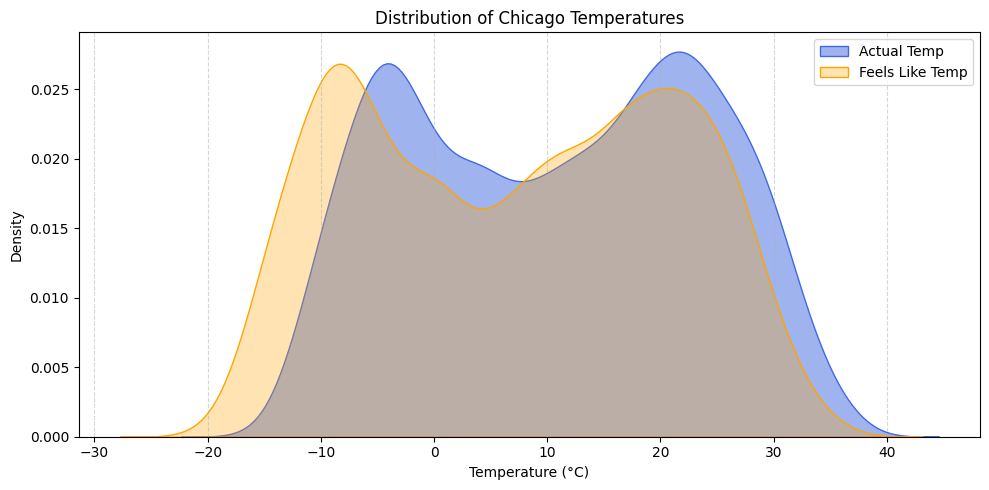

In [25]:
plt.figure(figsize=(10, 5))
sns.kdeplot(weather_data['temperature_2m'], label='Actual Temp', fill=True, color='royalblue', alpha=0.5)
sns.kdeplot(weather_data['apparent_temperature'], label='Feels Like Temp', fill=True, color='orange', alpha=0.3)

plt.title('Distribution of Chicago Temperatures')
plt.xlabel('Temperature (°C)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

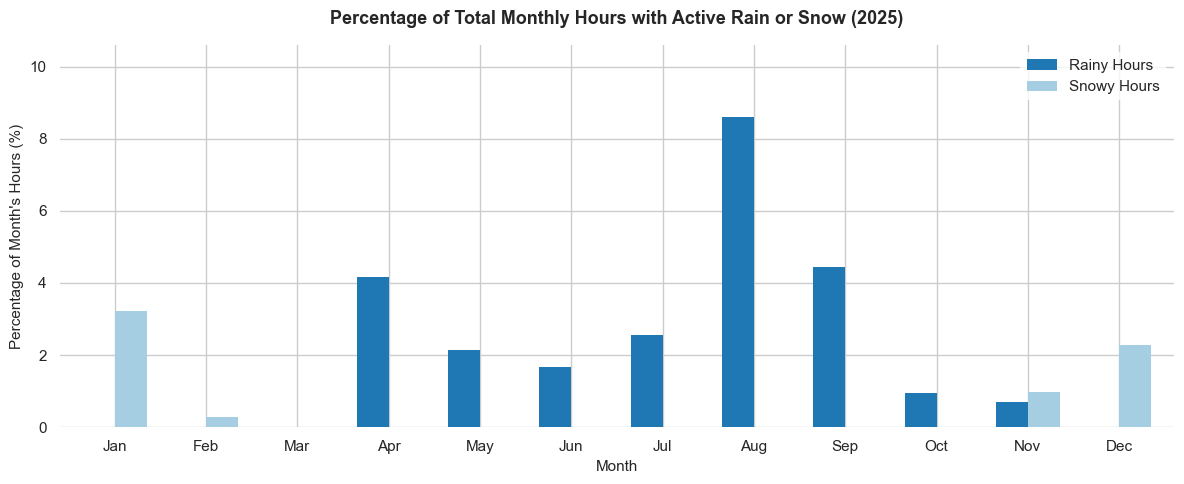

In [37]:
# 1. Create true boolean flags for active weather hours
weather_data['is_rain'] = weather_data['rain'] > 0
weather_data['is_snow'] = weather_data['snowfall'] > 0

# 2. Group by month and calculate the exact percentage of hours with active precipitation
monthly_shocks = weather_data.groupby('start_month').agg({
    'is_rain': 'mean',
    'is_snow': 'mean'
}) * 100  # Convert fractions to percentages

# Apply proper month names
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_shocks.index = month_labels
monthly_shocks.columns = ['Rainy Hours', 'Snowy Hours']

# 3. Plot side-by-side unstacked bars growing from the bottom up
sns.set_theme(style="whitegrid")
ax = monthly_shocks.plot(
    kind='bar', 
    figsize=(12, 5), 
    color=['#1f78b4', '#a6cee3'],  # Deep rain blue, light snow blue
    width=0.7,
    edgecolor='none'
)

# Clean up presentation
plt.title('Percentage of Total Monthly Hours with Active Rain or Snow (2025)', fontsize=13, pad=15, weight='bold')
plt.xlabel('Month', fontsize=11)
plt.ylabel('Percentage of Month\'s Hours (%)', fontsize=11)
plt.xticks(rotation=0)

# Zoom y-axis dynamically to just above the highest weather peak
plt.ylim(0, monthly_shocks.max().max() + 2) 

plt.legend(frameon=True, facecolor='white', edgecolor='none')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [ ]:
# Lets check if raw data contains precipitation for March
print("--- March Data Integrity Check ---")
march_data = weather_data[weather_data['start_month'] == 3]

print(f"Total hourly rows found for March: {len(march_data)}")
print(f"Hours where 'precipitation' > 0:  {(march_data['precipitation'] > 0).sum()}")
print(f"Hours where 'rain' > 0:           {(march_data['rain'] > 0).sum()}")
print(f"Hours where 'snowfall' > 0:       {(march_data['snowfall'] > 0).sum()}")

--- March Data Integrity Check ---
Total hourly rows found for March: 744
Hours where 'precipitation' > 0:  0
Hours where 'rain' > 0:           0
Hours where 'snowfall' > 0:       0


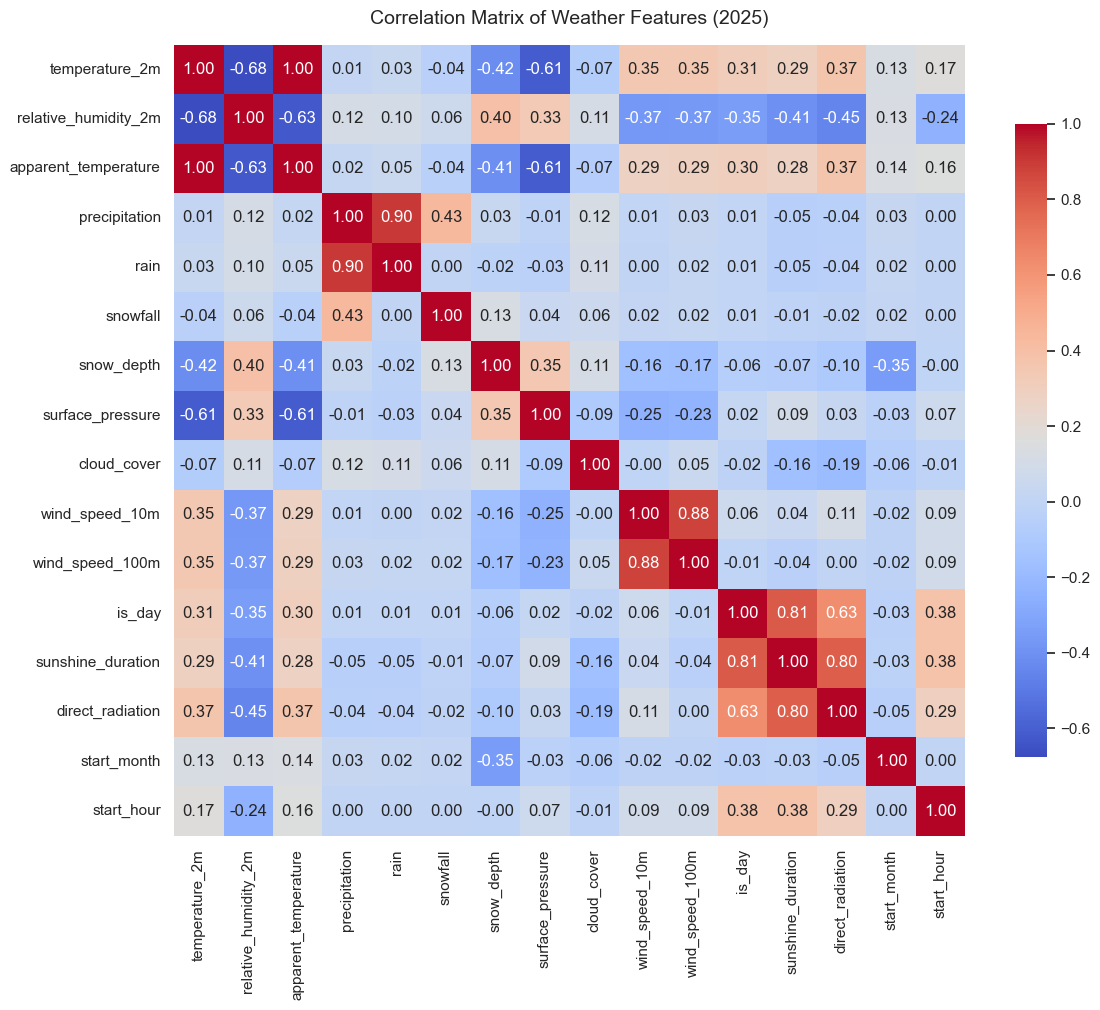

In [39]:
# Automatically select ONLY numeric columns for correlation
weather_numeric = weather_data.select_dtypes(include=['number'])

# Calculate the correlation matrix
corr_matrix = weather_numeric.corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={'shrink': .8})

plt.title('Correlation Matrix of Weather Features (2025)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()